# Functions

In [28]:
def df2list(df):
    """
    convert pandas' df into a list consist of dict.
    Args:
        df: dataframe
    Returns:
        dets: a list
    """
    dets = [{'bbox':row[['x','y','w','h']].values, 'centroid':row[['cX','cY']].values, "oval": row[["ellipse_w", "ellipse_h"]]} for _, row in df.iterrows()]
    return dets

def simple_iou_tracker(detections, t_min, sigma_iou=0.3):
    """
    simple IOU based tracker.
    Args:
        detections(list): list of detections per frame, 
        sigma_l(float): low detection threshold
        sigma_h(float): high detection threshold
        sigma_iou(float): IOU threshold
        t_min (float): minimum track length in frames.

    Returns:
        list: list of trackes.
    """
    tracks_active = []
    tracks_finished = []
    indx = 0
    for frame_num, detection_frame in enumerate(detections, start=1):
        dets = df2list(detection_frame)

        updated_tracks = []
        for track in tracks_active:
            if len(dets) > 0:
                best_match = max(dets, key=lambda x: iou(track['bboxes'][-1], x['bbox']))
                if iou(track['bboxes'][-1], best_match['bbox']) >= sigma_iou:
                    track['bboxes'].append(best_match['bbox'])
                    track['centroids'].append(best_match['centroid'])
                    track['ovals'].append(best_match['oval'])
                    track['end_frame'] = frame_num

                    updated_tracks.append(track)

                    
                    del dets[[i for i, _ in enumerate(dets) if all(_['centroid'] == best_match['centroid'])][0]]
                    # dets.index(best_match)
            if len(updated_tracks) == 0 or track is not updated_tracks[-1]:
                if len(track['bboxes']) >= t_min:
                    tracks_finished.append(track)
        new_tracks = [{'bboxes': [det['bbox']],
                       'centroids': [det['centroid']], 
                          'ovals': [det['oval']],
                       'start_frame': frame_num,
                       'end_frame': frame_num} for det in dets]
        tracks_active = updated_tracks + new_tracks
    tracks_finished += [track for track in tracks_active
                        if len(track['bboxes']) >= t_min]
    return tracks_finished

def Repeat(x):
    _size = len(x)
    repeated = []
    for i in range(_size):
        k = i + 1
        for j in range(k, _size):
            if x[i] == x[j] and x[i] not in repeated:
                repeated.append(x[i])
    return repeated
                
def bboxes2indx(df, trackers):
    """
    Args:
        df: dataframe
        trackers: list of trackers
    Returns:
        indx: list of index
    """
    indx = []
    for i, track in enumerate(trackers):
        find_all = np.all(np.array(track['bboxes']) == np.array(df[["x", "y", "w", "h"]]), axis=1)
        is_exists = np.any(find_all)
        the_frame = np.where(find_all == True)[0] + track['start_frame']
        # if is_exists and the_frame == df['frame'].values:
        if is_exists and the_frame == df['frame'].values:
            indx.append(i)
    return np.array(indx)

def df_iou(last_bbox,df):
    """
    df_iou: Calculating the IOU between one bboxes and all bboxes in a dataframe. And return the bboxes with IOU > 0.
    Args:
        last_bbox: a bbox
        df: a frame dataframe from all_dfs
    """
    return df[([iou(last_bbox, i) > 0 for i in np.array(df[["x" ,"y" ,"w" ,"h"]])])]

def find_initial(all_dfs, num, end_frame):
    """
    Args:
        all_dfs: list of dataframes
        num: int
    Returns:
        indx: list of index
    """
    len_df = np.array([len(df) for df in all_dfs[:end_frame-1]])
    indx_target = np.where(len_df >= num)[0]
    threshold = 1
    out = np.array_split(indx_target, np.flatnonzero(np.diff(indx_target) > threshold) + 1)

    return out[np.argmax([len(i) for i in out])]

In [29]:
def find_initial(long_dfs, num, trackers_summarize):
    """
    Args:
        long_dfs: list of dataframes
        num: int
    Returns:
        indx: list of index
    """
    counts_df = long_dfs.groupby("frame").size()
    counts_df.index = counts_df.index.astype(int)
    counts_df.columns = ['counts']

    indx_target = counts_df[counts_df >= num].index
    threshold = 1
    indx_split = np.split(indx_target, np.where(np.diff(indx_target) > threshold)[0] + 1)
    arg_max_split = np.argmax([len(i) for i in indx_split])
    frame_min, frame_max = indx_split[arg_max_split][0], indx_split[arg_max_split][-1]
    tmp_df = trackers_summarize.loc[(trackers_summarize['start_frame'] <= frame_min) & (trackers_summarize['end_frame'] >= frame_max)]

    return tmp_df

In [30]:
def generate_summarize(all_trackers):
    """
    Args:
        all_trackers: dict of trackers
    Returns:
        tmp_df: dataframe summarizing all trackers, consists of num, start_frame, end_frame, durations, start_bbox, end_bbox, start_centroids, end_centroids
    """
    tmp_df = pd.DataFrame(columns=["num", "start_frame", "end_frame", "durations", "start_bbox", "end_bbox", "start_centroids", "end_centroids"])
    for i in all_trackers:
        tmp_num = int(i)
        tmp_tracker = all_trackers[i]
        tmp_start_frame = tmp_tracker['start_frame']
        tmp_end_frame = tmp_tracker['end_frame']
        tmp_durations = tmp_end_frame - tmp_start_frame
        tmp_start_bbox = tmp_tracker['bboxes'][0]
        tmp_end_bbox = tmp_tracker['bboxes'][-1]
        tmp_start_centroids = tmp_tracker['centroids'][0]
        tmp_end_centroids = tmp_tracker['centroids'][-1]
        tmp_df.loc[len(tmp_df)] = [tmp_num, tmp_start_frame, tmp_end_frame, tmp_durations, tmp_start_bbox, tmp_end_bbox, tmp_start_centroids, tmp_end_centroids]
    return tmp_df

In [32]:
def find_bbox(all_trackers, bbox_df):
    tmp_indx = []
    tmp_frame = []
    for j in range(len(bbox_df)):
        bbox = bbox_df.iloc[j][["x", "y", "w", "h"]].values
        for i in all_trackers:
            indx = np.where(np.all(np.array(all_trackers[i]['bboxes']) == bbox, axis=1))[0]
            for k in indx:
                if (k + all_trackers[i]['start_frame']) in bbox_df.index:
                    tmp_indx.append(int(i))
                    tmp_frame.append(bbox_df.index.values[0])
    return tmp_indx, tmp_frame

def right_find(tmp_df, long_dfs):
    """
    Args:
        trackers_summarize: dataframe summarizing all trackers, consists of num, start_frame, end_frame, durations, start_bbox, end_bbox, start_centroids, end_centroids
        long_dfs: the information of each frame in a video
    Returns:
    """

    tmp_end_bbox = tmp_df.end_bbox
    tmp_end_frame = tmp_df.end_frame

    return df_iou(tmp_end_bbox,long_dfs.loc[[tmp_end_frame + 1]])

def left_find(tmp_df, long_dfs):
    """
    Args:
        trackers_summarize: dataframe summarizing all trackers, consists of num, start_frame, end_frame, durations, start_bbox, end_bbox, start_centroids, end_centroids
        long_dfs: the information of each frame in a video
    Returns:
    """

    tmp_start_bbox = tmp_df.start_bbox
    tmp_start_frame = tmp_df.start_frame

    return df_iou(tmp_start_bbox,long_dfs.loc[[tmp_start_frame - 1]])

def edge_type(tmp_df, long_dfs, all_trackers):
    """
    Args:
        trackers_summarize: dataframe summarizing all trackers, consists of num, start_frame, end_frame, durations, start_bbox, end_bbox, start_centroids, end_centroids
        long_dfs: the information of each frame in a video
    Returns:
    """

    if tmp_df.start_frame-1 not in long_dfs.index:
        left_prev = ([], [])
    else:
        left_find_df = left_find(tmp_df, long_dfs)
        left_prev = find_bbox(all_trackers, left_find_df)

    if tmp_df.end_frame+1 not in long_dfs.index:
        right_next = ([], [])
    else:
        right_find_df = right_find(tmp_df, long_dfs)
        right_next = find_bbox(all_trackers, right_find_df)

    if len(right_next[0]) == 0:
        tmp_right_type = "disappear"
    elif len(right_next[0]) == 1:
        tmp_right_type = "merge"
    elif len(right_next[0]) > 1:
        tmp_right_type = "split"

    if len(left_prev[0]) == 0:
        tmp_left_type = "appear"
    elif len(left_prev[0]) == 1:
        tmp_left_type = "split"
    elif len(left_prev[0]) > 1:
        tmp_left_type = "merge"


    return tmp_left_type, tmp_right_type, left_prev, right_next

In [33]:
# tmp methods for conn_disappear
def conn_disappear_next(tmp_df, merge_trackers_summarize):
    tmp_end_frame = tmp_df.end_frame
    tmp_end_centroids = tmp_df.end_centroids
    tmp_end_bbox = tmp_df.end_bbox

    indx_frame = (merge_trackers_summarize.start_frame > tmp_end_frame) & ((merge_trackers_summarize.start_frame - tmp_end_frame) <= 100) & (merge_trackers_summarize.left_type == "appear")

    tmp_next_df = merge_trackers_summarize.loc[indx_frame]
    if len(tmp_next_df) == 0:
        return "can't find"
    else:
        for i in range(len(tmp_next_df)):
            if iou(tmp_next_df.iloc[i].start_bbox, tmp_end_bbox) > 0:
                return tmp_next_df.iloc[i].num
            if np.linalg.norm(np.array(tmp_next_df.iloc[i].start_centroids) - np.array(tmp_end_centroids)) / np.abs(tmp_next_df.iloc[i].start_frame - tmp_end_frame) < 5:
                return tmp_next_df.iloc[i].num
        return "can't find"


In [34]:
def split_from(num, merge_trackers_summarize):
    tmp_df = merge_trackers_summarize
    tmp_df_1 = tmp_df.loc[[num in j[0] for j in tmp_df.left_prev]]

    this_end = tmp_df.loc[tmp_df.num == num].end_frame.values
    this_start = tmp_df.loc[tmp_df.num == num].start_frame.values

    result_df = pd.DataFrame(columns=["this_num", "nex_num", "this_start", "this_end", "nex_start", "nex_end"])
    result_df.loc[len(result_df)] = [num, tmp_df_1.num.values, this_start, this_end, tmp_df_1.start_frame.values, tmp_df_1.end_frame.values]
    result_df['difference'] = np.abs(result_df.nex_start - result_df.this_end) - 1
    result_df['is_split'] = np.any(result_df['difference'].values[0])

    return result_df

def merge_to(num, merge_new_summarize):
    tmp_df = merge_new_summarize
    tmp_df_1 = tmp_df.loc[[num in j[0] for j in tmp_df.right_next]]

    this_end = tmp_df.loc[tmp_df.num == num].end_frame.values
    this_start = tmp_df.loc[tmp_df.num == num].start_frame.values

    result_df = pd.DataFrame(columns=["this_num", "nex_num", "this_start", "this_end", "nex_start", "nex_end"])
    result_df.loc[len(result_df)] = [num, tmp_df_1.num.values, this_start, this_end, tmp_df_1.start_frame.values, tmp_df_1.end_frame.values]
    result_df['difference'] = np.abs(result_df.nex_end - result_df.this_start) - 1
    result_df['is_merge'] = np.any(result_df['difference'].values[0])
    return result_df

def split_tracker(tracker, frame):
    """
    Args:
        tracker: dict of tracker
        frame: int
    Returns:
        new_tracker: dict of tracker
    """
    new_tracker1 = {}       
    new_tracker1['bboxes'] = tracker['bboxes'][:(frame - tracker['start_frame'] + 1)]
    new_tracker1['centroids'] = tracker['centroids'][:(frame - tracker['start_frame'] + 1)]
    new_tracker1['start_frame'] = tracker['start_frame']
    new_tracker1['end_frame'] = frame
    new_tracker2 = {}
    new_tracker2['bboxes'] = tracker['bboxes'][(frame - tracker['start_frame'] + 1):]
    new_tracker2['centroids'] = tracker['centroids'][(frame - tracker['start_frame']+1):]
    new_tracker2['start_frame'] = frame + 1
    new_tracker2['end_frame'] = tracker['end_frame']
    return new_tracker1, new_tracker2



def split_trackers(this_num, all_critical_split_df, all_trackers):
    sorted_df = all_critical_split_df.loc[all_critical_split_df.tracker_num == this_num].sort_values('split_frame')
    this_tracker = all_trackers[this_num]

    tmp_str = []
    for i in range(len(sorted_df)):
        split_frame = sorted_df.iloc[i].split_frame - 1
        t1, t2 = split_tracker(this_tracker, split_frame)
        this_tracker = split_tracker(this_tracker, split_frame)[1]

        if i < len(sorted_df) - 1:
            tmp_str.append(t1)
        else:
            tmp_str.append(t1)
            tmp_str.append(t2)
    return tmp_str

In [35]:
def find_next(num, merge_summary_df):
    """
    Args:
        num: int
        merge_summary_df: dataframe
    Returns:
        next_num: int
    """
    tmp_df = merge_summary_df.loc[num]
    result_df = pd.DataFrame(columns=['this_num', 'nex_num', 'right_type'])
    if tmp_df.right_type == "disappear":
        result_df.loc[len(result_df)] = [num, conn_disappear_next(tmp_df, merge_summary_df), "disappear"]
    else:
        for i in tmp_df.right_next[0]:
            result_df.loc[len(result_df)] = [num, i, tmp_df.right_type]
    return result_df

def find_all_nex(start_num, merge_summary_df, store_dict = [], banned_list = []):
    find_next_df = find_next(start_num, merge_summary_df)
    store_dict.append(find_next_df)
    # print("${} find next: {}".format(start_num, find_next_df.nex_num.values))
    # print("$is in banned list: {}".format([i in banned_list for i in find_next_df.nex_num.values]))
    if np.all([i in banned_list for i in find_next_df.nex_num.values]):
        print("${} all path banned".format(find_next_df.nex_num.values))
        store_dict.append("all_path_banned")
        return "all_path_banned"
    if type(find_next_df.nex_num.values[0]) != str:
        rand_int = np.random.randint(0, len(find_next_df))
        while find_next_df.nex_num.values[rand_int] in banned_list:
            rand_int = np.random.randint(0, len(find_next_df))
        find_all_nex(find_next_df.nex_num.values[rand_int], merge_summary_df, store_dict, banned_list)

def simple_find_nex(start_num, merge_df, banned_list):
    multi_index = merge_new_summarize.loc[(merge_new_summarize.right_type == "split") | (merge_new_summarize.left_type == "merge")].index.values
    tmp_list = []
    find_all_nex(start_num, merge_df, tmp_list, banned_list)
    t_num = [i.this_num.values for i in tmp_list if type(i) != str]
    tmp_num = np.concatenate(t_num)
    indexes = np.unique(tmp_num, return_index=True)[1]
    worm = np.array([tmp_num[i] for i in sorted(indexes)])
    new_banned_list = worm[np.where([i not in multi_index for i in worm])[0]]
    new_banned_list = np.unique(np.concatenate([banned_list, new_banned_list]))
    if type(tmp_list[-1]) == str:
        worm = np.concatenate([worm, [-1]] )

    return worm, new_banned_list
        

In [36]:
def conn_disappear_prev(tmp_df, merge_trackers_summarize):
    tmp_start_frame = tmp_df.start_frame
    tmp_start_centroids = tmp_df.start_centroids
    tmp_start_bbox = tmp_df.start_bbox

    indx_frame = (merge_trackers_summarize.end_frame < tmp_start_frame) & (np.abs(merge_trackers_summarize.end_frame - tmp_start_frame) <= 100) & (merge_trackers_summarize.right_type == "disappear")

    tmp_prev_df = merge_trackers_summarize.loc[indx_frame]
    if len(tmp_prev_df) == 0:
        return "can't find"
    else:
        for i in range(len(tmp_prev_df)):
            if iou(tmp_prev_df.iloc[i].end_bbox, tmp_start_bbox) > 0:
                return tmp_prev_df.iloc[i].num
            if np.linalg.norm(np.array(tmp_prev_df.iloc[i].start_centroids) - np.array(tmp_start_centroids)) / np.abs(tmp_prev_df.iloc[i].start_frame - tmp_start_frame) < 5:
                return tmp_prev_df.iloc[i].num
        return "can't find"

def find_prev(num, merge_summary_df):
    """
    Args:
        num: int
        merge_summary_df: dataframe
    Returns:
        next_num: int
    """
    tmp_df = merge_summary_df.loc[num]
    result_df = pd.DataFrame(columns=['this_num', 'prev_num', 'left_type'])
    if tmp_df.left_type == "appear":
        result_df.loc[len(result_df)] = [num, conn_disappear_prev(tmp_df, merge_summary_df), "appear"]
    else:
        for i in tmp_df.left_prev[0]:
            result_df.loc[len(result_df)] = [num, i, tmp_df.left_type]
    return result_df

def find_all_prev(start_num, merge_summary_df, store_dict = [], banned_list = []):
    find_prev_df = find_prev(start_num, merge_summary_df)
    store_dict.insert(0, find_prev_df)
    # print("${} find next: {}".format(start_num, find_next_df.nex_num.values))
    # print("$is in banned list: {}".format([i in banned_list for i in find_next_df.nex_num.values]))
    if np.all([i in banned_list for i in find_prev_df.prev_num.values]):
        print("${} all path banned".format(find_prev_df.prev_num.values))
        store_dict.insert(0,"all_path_banned")
        return "all_path_banned"
    if type(find_prev_df.prev_num.values[0]) != str:
        rand_int = np.random.randint(0, len(find_prev_df))
        while find_prev_df.prev_num.values[rand_int] in banned_list:
            rand_int = np.random.randint(0, len(find_prev_df))
        find_all_prev(find_prev_df.prev_num.values[rand_int], merge_summary_df, store_dict, banned_list)


def simple_find_prev(start_num, merge_df, banned_list):
    multi_index = merge_new_summarize.loc[(merge_new_summarize.right_type == "split") | (merge_new_summarize.left_type == "merge")].index.values
    tmp_list = []
    find_all_prev(start_num, merge_df, tmp_list, banned_list)
    t_num = [i.this_num.values for i in tmp_list if type(i) != str]
    tmp_num = np.concatenate(t_num)
    indexes = np.unique(tmp_num, return_index=True)[1]
    worm = np.array([tmp_num[i] for i in sorted(indexes)])
    new_banned_list = worm[np.where([i not in multi_index for i in worm])[0]]
    new_banned_list = np.unique(np.concatenate([banned_list, new_banned_list]))
    if type(tmp_list[0]) == str:
        worm = np.concatenate([[-1], worm])

    return worm, new_banned_list
        

# Apply_1

1. 读取利用 Processing_1 得到的 `trackers` 和 `long_dfs`；
    - `trackers` 记录了每段 `tracker` 的起始帧，终结帧，bboxes 和中心位置。
    - `long_dfs` 记录了每一帧所探测到的所有 `bboxes` 和 `centroids`

In [10]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import re

from plotly.tools import mpl_to_plotly
import plotly.io as pio
from tracker.iou import *

In [11]:
csv_dicts = dict()
match_num = r"(\d+).csv"
for root, dirs, files in os.walk("results"):
    tmp_files = []
    for file in files:
        if file.endswith(".csv"):
            tmp_files.append(file)
    if len(tmp_files):
        csv_dicts[root.split(os.sep)[1]] = [root,tmp_files]

for k in csv_dicts.keys():
    csv_dicts[k][1].sort(key = lambda x: int(re.findall(match_num, x)[0]))
    subj = csv_dicts[k]
    all_dfs = [pd.read_csv(os.path.join(subj[0], i)) for i in subj[1]]
    all_trackers = simple_iou_tracker(all_dfs,10, 0.3)
    all_subjects_dict = {}
    for i, tracker in enumerate(all_trackers):
        all_subjects_dict[i] = {"start_frame": tracker['start_frame'], "end_frame": tracker['end_frame'], "bboxes": np.array(tracker['bboxes']).tolist(), "centroids": np.array(tracker['centroids']).tolist(),
                                "ovals": np.array(tracker['ovals']).tolist()}
    with open('./{}_trackers.json'.format(k), 'w') as f:
        json.dump(all_subjects_dict, f)
    pd.concat(all_dfs, ignore_index=True).to_csv('./{}_dfs.csv'.format(k), index=False)

IndexError: list index out of range

In [13]:
with open('N2_Naive1_trackers.json', "r") as f:
    all_trackers = json.load(f)
long_dfs = pd.read_csv('N2_Naive1_dfs.csv', index_col="frame")
long_dfs.index = long_dfs.index.astype(int)
all_trackers = {int(k): v for k, v in all_trackers.items()}

trackers_summarize = generate_summarize(all_trackers)
trackers_type_df = pd.DataFrame(columns=["num", "left_type", "right_type", "left_prev", "right_next"])
for i in range(len(trackers_summarize)):
    tmp_df = trackers_summarize.iloc[i]
    tmp_left_type, tmp_right_type, left_prev, right_next = edge_type(tmp_df, long_dfs, all_trackers)
    trackers_type_df.loc[len(trackers_type_df)] = [tmp_df.num, tmp_left_type, tmp_right_type, left_prev, right_next]
    
merge_trackers_summarize = pd.merge(trackers_summarize, trackers_type_df, on="num")

In [15]:
split_from_df = pd.concat([split_from(i, merge_trackers_summarize) for i in range(len(merge_trackers_summarize))], ignore_index=True)
split_from_df = split_from_df.loc[split_from_df.is_split == True]
tmp_all_num = []
for i in range(len(split_from_df)):
    nex_num = split_from_df.iloc[i].nex_num
    diff = split_from_df.iloc[i]['difference']
    nex_start = split_from_df.iloc[i]["nex_start"]
    this_num = split_from_df.iloc[i].this_num

    tmp_df = pd.DataFrame(columns=['tracker_num', 'split_frame'])

    for i,j in zip(nex_start, diff):
        if j != 0:
            tmp_df.loc[len(tmp_df)] = [this_num, i]
    tmp_all_num.append(tmp_df)
    # print(tmp_df)
critical_split_df = pd.concat(tmp_all_num, ignore_index=True)

In [16]:
new_trackers = {}
ini_indx = 0
for i in range(len(all_trackers)):
    if i not in critical_split_df.tracker_num.values:
        new_trackers[ini_indx] = all_trackers[i]
        ini_indx += 1
    else:
        split_result = split_trackers(i, critical_split_df, all_trackers)
        for j in split_result:
            new_trackers[ini_indx] = j
            ini_indx += 1


In [17]:
new_summarize = generate_summarize(new_trackers)
trackers_type_df = pd.DataFrame(columns=["num", "left_type", "right_type", "left_prev", "right_next"])
for i in range(len(new_summarize)):
    tmp_df = new_summarize.iloc[i]
    tmp_left_type, tmp_right_type, left_prev, right_next = edge_type(tmp_df, long_dfs, new_trackers)
    trackers_type_df.loc[len(trackers_type_df)] = [tmp_df.num, tmp_left_type, tmp_right_type, left_prev, right_next]
    
merge_new_summarize = pd.merge(new_summarize, trackers_type_df, on="num")

In [18]:
merge_to_df = pd.concat([merge_to(i, merge_new_summarize) for i in range(len(merge_new_summarize))], ignore_index=True)
merge_to_df = merge_to_df.loc[merge_to_df.is_merge == True]
tmp_all_num = []
for i in range(len(merge_to_df)):
    diff = merge_to_df.iloc[i]['difference']
    nex_start = merge_to_df.iloc[i]["nex_end"]
    this_num = merge_to_df.iloc[i].this_num

    tmp_df = pd.DataFrame(columns=['tracker_num', 'split_frame'])

    for i,j in zip(nex_start, diff):
        if j != 0:
            tmp_df.loc[len(tmp_df)] = [this_num, i]
    tmp_all_num.append(tmp_df)
    # print(tmp_df)
critical_merge_df = pd.concat(tmp_all_num, ignore_index=True)
critical_merge_df.split_frame += 1

In [19]:
new_trackers_2 = {}
ini_indx = 0
for i in range(len(new_trackers)):
    if i not in critical_merge_df.tracker_num.values:
        new_trackers_2[ini_indx] = new_trackers[(i)]
        ini_indx += 1
    else:
        split_result = split_trackers(i, critical_merge_df, new_trackers)
        for j in split_result:
            new_trackers_2[ini_indx] = j
            ini_indx += 1


In [20]:
new_summarize_2 = generate_summarize(new_trackers_2)

trackers_type_df = pd.DataFrame(columns=["num", "left_type", "right_type", "left_prev", "right_next"])
for i in range(len(new_summarize_2)):
    tmp_df = new_summarize_2.iloc[i]
    tmp_left_type, tmp_right_type, left_prev, right_next = edge_type(tmp_df, long_dfs, new_trackers_2)
    trackers_type_df.loc[len(trackers_type_df)] = [tmp_df.num, tmp_left_type, tmp_right_type, left_prev, right_next]

In [21]:
merge_new_summarize = pd.merge(new_summarize_2, trackers_type_df, on="num")

In [37]:
find_initial(long_dfs, 10, merge_new_summarize)

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next
37,37,1241,3974,2733,"[1830.0, 939.0, 17.0, 7.0]","[1593.0, 805.0, 10.0, 16.0]","[1838.513725490196, 941.3215686274508]","[1597.7062706270626, 812.1848184818481]",split,merge,"([42], [1240])","([39], [3975])"
38,38,1262,3974,2712,"[1764.0, 902.0, 17.0, 12.0]","[1598.0, 822.0, 10.0, 20.0]","[1773.1666666666663, 907.5089285714286]","[1601.9749373433583, 831.3884711779448]",split,merge,"([29], [1261])","([39], [3975])"
43,43,1241,4132,2891,"[1832.0, 946.0, 11.0, 17.0]","[1960.0, 1136.0, 12.0, 6.0]","[1835.9166666666667, 954.8333333333334]","[1965.4782608695648, 1138.4565217391305]",split,disappear,"([42], [1240])","([], [])"
45,45,2832,5132,2300,"[1651.0, 954.0, 10.0, 21.0]","[1743.0, 1042.0, 9.0, 18.0]","[1655.3794871794871, 964.5076923076924]","[1746.6055555555554, 1051.0194444444444]",split,merge,"([36], [2831])","([57], [5133])"
46,46,2427,5296,2869,"[1818.0, 803.0, 19.0, 8.0]","[1555.0, 865.0, 20.0, 9.0]","[1827.775757575757, 807.1090909090909]","[1564.573770491803, 869.0245901639345]",split,merge,"([31], [2426])","([53], [5297])"
56,56,635,5132,4497,"[1694.0, 1064.0, 9.0, 7.0]","[1730.0, 1043.0, 13.0, 15.0]","[1698.0077519379845, 1066.798449612403]","[1735.8259587020648, 1049.961651917404]",appear,merge,"([], [])","([57], [5133])"
82,82,2832,6923,4091,"[1660.0, 972.0, 20.0, 9.0]","[1529.0, 1001.0, 10.0, 14.0]","[1669.5457227138645, 975.849557522124]","[1532.917404129793, 1008.315634218289]",split,merge,"([36], [2831])","([86], [6924])"
95,95,160,6720,6560,"[1864.0, 918.0, 9.0, 12.0]","[1654.0, 948.0, 15.0, 16.0]","[1867.6041666666663, 922.4635416666666]","[1660.4037940379403, 955.4254742547424]",appear,merge,"([], [])","([96], [6721])"
113,113,2695,10673,7978,"[1831.0, 791.0, 15.0, 13.0]","[1906.0, 669.0, 12.0, 5.0]","[1838.5990990990988, 798.0675675675676]","[1911.5652173913045, 670.9782608695652]",appear,disappear,"([], [])","([], [])"
147,147,65,15003,14938,"[1575.0, 1117.0, 10.0, 6.0]","[1265.0, 498.0, 13.0, 12.0]","[1579.296296296296, 1119.3925925925926]","[1271.7105263157894, 503.8157894736842]",appear,disappear,"([], [])","([], [])"


In [38]:
all_ini = find_initial(long_dfs, 10, merge_new_summarize)
tmp_indx = all_ini.sort_values(by="start_frame").num.values

In [55]:
worm10[1]

6

In [50]:
merge_new_summarize.loc[[6]]

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next
6,6,71,532,461,"[1649.0, 1016.0, 8.0, 7.0]","[1732.0, 1042.0, 20.0, 9.0]","[1652.3739837398373, 1019.4878048780488]","[1741.910144927536, 1046.5478260869563]",appear,disappear,"([], [])","([], [])"


In [42]:
banned_list = np.array([])
worm1, banned_list = simple_find_nex(tmp_indx[0], merge_new_summarize, banned_list)
worm2, banned_list = simple_find_nex(tmp_indx[1], merge_new_summarize, banned_list)
worm3, banned_list = simple_find_nex(tmp_indx[2], merge_new_summarize, banned_list)
worm4, banned_list = simple_find_nex(tmp_indx[3], merge_new_summarize, banned_list)
worm5, banned_list = simple_find_nex(tmp_indx[4], merge_new_summarize, banned_list)
worm6, banned_list = simple_find_nex(tmp_indx[5], merge_new_summarize, banned_list)
worm7, banned_list = simple_find_nex(tmp_indx[6], merge_new_summarize, banned_list)
worm8, banned_list = simple_find_nex(tmp_indx[7], merge_new_summarize, banned_list)
worm9, banned_list = simple_find_nex(tmp_indx[8], merge_new_summarize, banned_list)
worm10, banned_list = simple_find_nex(tmp_indx[9], merge_new_summarize, banned_list)

banned_list_prev = banned_list
worm5_prev, banned_list_prev = simple_find_prev(tmp_indx[4], merge_new_summarize, banned_list_prev)
worm6_prev, banned_list_prev = simple_find_prev(tmp_indx[5], merge_new_summarize, banned_list_prev)
worm7_prev, banned_list_prev = simple_find_prev(tmp_indx[6], merge_new_summarize, banned_list_prev)
worm8_prev, banned_list_prev = simple_find_prev(tmp_indx[7], merge_new_summarize, banned_list_prev)
worm9_prev, banned_list_prev = simple_find_prev(tmp_indx[8], merge_new_summarize, banned_list_prev)
worm10_prev, banned_list_prev = simple_find_prev(tmp_indx[9], merge_new_summarize, banned_list_prev)
worm5 = np.concatenate([worm5_prev[:-1], worm5])
worm6 = np.concatenate([worm6_prev[:-1], worm6])
worm7 = np.concatenate([worm7_prev[:-1], worm7])
worm8 = np.concatenate([worm8_prev[:-1], worm8])
worm9 = np.concatenate([worm9_prev[:-1], worm9])
worm10 = np.concatenate([worm10_prev[:-1], worm10])

error_worm_indx = []
for i in range(1, 11):
    tmp_worm = eval("worm{}".format(i))
    if tmp_worm[-1] == -1:
        error_worm_indx.append(i)
        print("worm{} is a dead end".format(i))
    if tmp_worm[0] == -1:
        error_worm_indx.append(i)
        print("worm{} is a dead start".format(i))
    
print(np.unique(error_worm_indx).shape[0])

$[47] all path banned
$[0] all path banned
$[0] all path banned
$[0] all path banned
$[0] all path banned
worm6 is a dead end
worm6 is a dead start
worm8 is a dead start
worm9 is a dead start
worm10 is a dead start
4


/var/folders/bp/zrhn927j6wjb46f6rnsdj9g00000gn/T/ipykernel_73682/2017363757.py:23: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/var/folders/bp/zrhn927j6wjb46f6rnsdj9g00000gn/T/ipykernel_73682/2017363757.py:23: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/var/folders/bp/zrhn927j6wjb46f6rnsdj9g00000gn/T/ipykernel_73682/2017363757.py:23: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/var/folders/bp/zrhn927j6wjb46f6rnsdj9g00000gn/T/ipykernel_73682/2017363757.py:23: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/var/folders/bp/zrhn927j6wjb46f6rnsdj9g00000gn/T/ipykernel_73682/2017363757.py:23: FutureWarning:

elementwise comparison failed; returning scalar instead, 

In [43]:
new_path = "n21_old"
os.path.isdir(new_path) and shutil.rmtree(new_path)
os.path.isdir(new_path) or os.makedirs(new_path)
for k in range(1, 11):
    if k in error_worm_indx:
        continue
    tmp_worm = eval("worm{}".format(k))
    fig,ax = plt.subplots(figsize=(15,10))
    for i,j in enumerate(tmp_worm):
        # print(j)
        ax.plot(*np.array(new_trackers_2[j]['centroids'][::]).T, label=i)
        if j != tmp_worm[-1]:
            tmp_indx = tmp_worm[i+1]
            ax.plot(*np.array([new_trackers_2[j]['centroids'][-1], new_trackers_2[tmp_indx]['centroids'][0]]).T, 'k-.')


    ax.set_xlim(0, 3072)
    ax.set_ylim(0, 2048)
    ax.legend()
    plotly_fig = mpl_to_plotly(fig)
    pio.write_html(plotly_fig, file=os.path.join(new_path,"worm{:02d}.html".format(k)), auto_open=True)


/Users/zhengpanpan/miniconda3/envs/worm-tracker/lib/python3.9/site-packages/plotly/matplotlylib/renderer.py:609: UserWarning:

I found a path object that I don't think is part of a bar chart. Ignoring.

/Users/zhengpanpan/miniconda3/envs/worm-tracker/lib/python3.9/site-packages/plotly/matplotlylib/renderer.py:609: UserWarning:

I found a path object that I don't think is part of a bar chart. Ignoring.



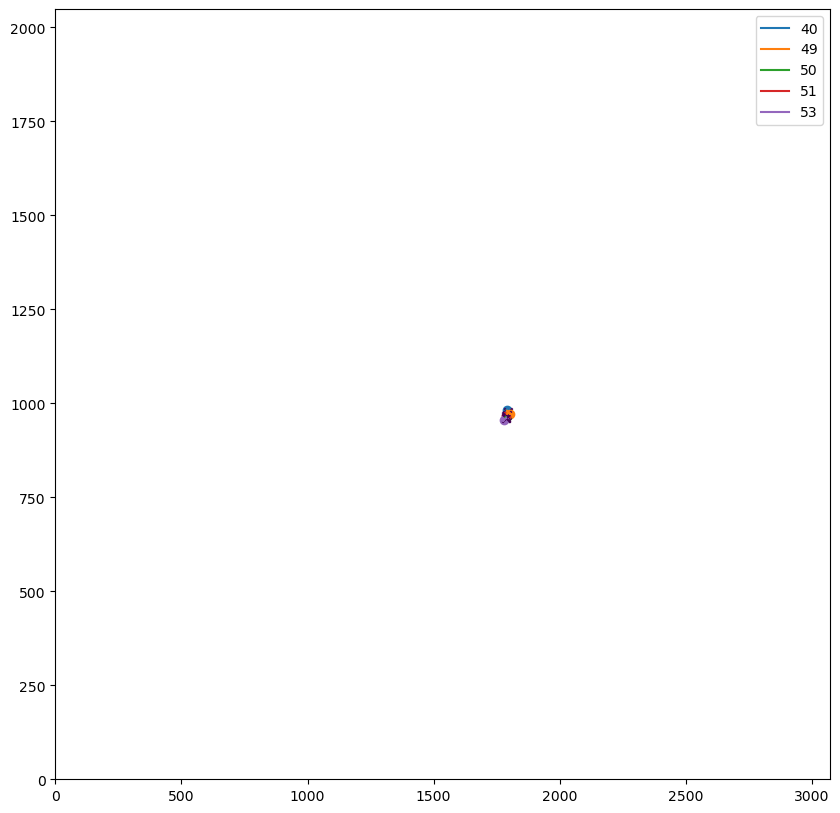

In [21]:
fig,ax = plt.subplots(figsize=(10,10))
for i in worm1[5:10]:

    plt.plot(*np.array(new_trackers_2[i]['centroids'][::5]).T, label=i)
    plt.scatter(*np.array(new_trackers_2[i]['centroids'][0]).T)
    plt.scatter(*np.array(new_trackers_2[i]['centroids'][-1]).T, marker='x', c=1)



ax.set_xlim(0, 3072)
ax.set_ylim(0, 2048)
ax.legend()


# Apply2

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# from iou import *

In [56]:
with open('N2_naive2_trackers.json', "r") as f:
    all_trackers = json.load(f)
long_dfs = pd.read_csv('N2_naive2_dfs.csv', index_col="frame")
long_dfs.index = long_dfs.index.astype(int)
all_trackers = {int(k): v for k, v in all_trackers.items()}

trackers_summarize = generate_summarize(all_trackers)
trackers_type_df = pd.DataFrame(columns=["num", "left_type", "right_type", "left_prev", "right_next"])
for i in range(len(trackers_summarize)):
    tmp_df = trackers_summarize.iloc[i]
    tmp_left_type, tmp_right_type, left_prev, right_next = edge_type(tmp_df, long_dfs, all_trackers)
    trackers_type_df.loc[len(trackers_type_df)] = [tmp_df.num, tmp_left_type, tmp_right_type, left_prev, right_next]
    
merge_trackers_summarize = pd.merge(trackers_summarize, trackers_type_df, on="num")
print(len(all_trackers))


29


In [57]:
split_from_df = pd.concat([split_from(i, merge_trackers_summarize) for i in range(len(merge_trackers_summarize))], ignore_index=True)
split_from_df = split_from_df.loc[split_from_df.is_split == True]
tmp_all_num = []
for i in range(len(split_from_df)):
    nex_num = split_from_df.iloc[i].nex_num
    diff = split_from_df.iloc[i]['difference']
    nex_start = split_from_df.iloc[i]["nex_start"]
    this_num = split_from_df.iloc[i].this_num

    tmp_df = pd.DataFrame(columns=['tracker_num', 'split_frame'])

    for i,j in zip(nex_start, diff):
        if j != 0:
            tmp_df.loc[len(tmp_df)] = [this_num, i]
    tmp_all_num.append(tmp_df)
    # print(tmp_df)
critical_split_df = pd.concat(tmp_all_num, ignore_index=True)

new_trackers = {}
ini_indx = 0
for i in range(len(all_trackers)):
    if i not in critical_split_df.tracker_num.values:
        new_trackers[ini_indx] = all_trackers[i]
        ini_indx += 1
    else:
        split_result = split_trackers(i, critical_split_df, all_trackers)
        for j in split_result:
            new_trackers[ini_indx] = j
            ini_indx += 1


In [58]:
new_summarize = generate_summarize(new_trackers)
trackers_type_df = pd.DataFrame(columns=["num", "left_type", "right_type", "left_prev", "right_next"])
for i in range(len(new_summarize)):
    tmp_df = new_summarize.iloc[i]
    tmp_left_type, tmp_right_type, left_prev, right_next = edge_type(tmp_df, long_dfs, new_trackers)
    trackers_type_df.loc[len(trackers_type_df)] = [tmp_df.num, tmp_left_type, tmp_right_type, left_prev, right_next]
    
merge_new_summarize = pd.merge(new_summarize, trackers_type_df, on="num")

In [59]:
merge_to_df = pd.concat([merge_to(i, merge_new_summarize) for i in range(len(merge_new_summarize))], ignore_index=True)
merge_to_df = merge_to_df.loc[merge_to_df.is_merge == True]
tmp_all_num = []
for i in range(len(merge_to_df)):
    diff = merge_to_df.iloc[i]['difference']
    nex_start = merge_to_df.iloc[i]["nex_end"]
    this_num = merge_to_df.iloc[i].this_num

    tmp_df = pd.DataFrame(columns=['tracker_num', 'split_frame'])

    for i,j in zip(nex_start, diff):
        if j != 0:
            tmp_df.loc[len(tmp_df)] = [this_num, i]
    tmp_all_num.append(tmp_df)
    # print(tmp_df)
critical_merge_df = pd.concat(tmp_all_num, ignore_index=True)
critical_merge_df.split_frame += 1

new_trackers_2 = {}
ini_indx = 0
for i in range(len(new_trackers)):
    if i not in critical_merge_df.tracker_num.values:
        new_trackers_2[ini_indx] = new_trackers[(i)]
        ini_indx += 1
    else:
        split_result = split_trackers(i, critical_merge_df, new_trackers)
        for j in split_result:
            new_trackers_2[ini_indx] = j
            ini_indx += 1

In [60]:
new_summarize_2 = generate_summarize(new_trackers_2)

trackers_type_df = pd.DataFrame(columns=["num", "left_type", "right_type", "left_prev", "right_next"])
for i in range(len(new_summarize_2)):
    tmp_df = new_summarize_2.iloc[i]
    tmp_left_type, tmp_right_type, left_prev, right_next = edge_type(tmp_df, long_dfs, new_trackers_2)
    trackers_type_df.loc[len(trackers_type_df)] = [tmp_df.num, tmp_left_type, tmp_right_type, left_prev, right_next]

merge_new_summarize = pd.merge(new_summarize_2, trackers_type_df, on="num")

<Axes: xlabel='frame'>

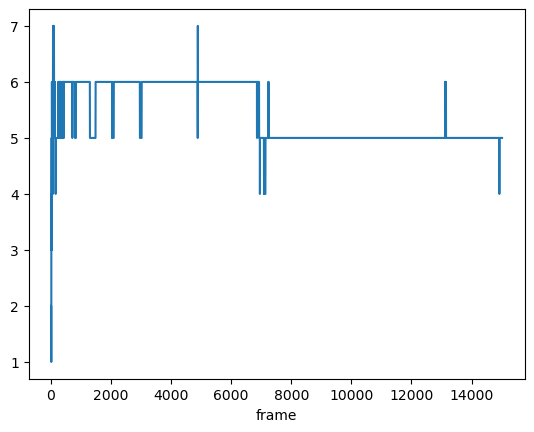

In [73]:
long_dfs.groupby("frame").size().plot()

In [105]:
all_ini = find_initial(long_dfs, 6, merge_new_summarize)
tmp_indx = all_ini.sort_values(by="start_frame").num.values
all_ini

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next
26,26,830,6856,6026,"[1430.0, 895.0, 16.0, 12.0]","[1181.0, 1347.0, 14.0, 5.0]","[1437.4186666666665, 900.6186666666666]","[1187.2, 1348.6933333333332]",split,disappear,"([11], [829])","([], [])"
27,27,11,6925,6914,"[1669.0, 901.0, 10.0, 6.0]","[1497.0, 1903.0, 9.0, 6.0]","[1673.6028368794323, 903.3900709219856]","[1500.9130434782608, 1905.4492753623183]",appear,disappear,"([], [])","([], [])"
29,29,3017,7087,4070,"[1692.0, 1047.0, 8.0, 21.0]","[1499.0, 1516.0, 9.0, 20.0]","[1695.1465721040188, 1056.5200945626475]","[1503.4696016771488, 1525.8595387840671]",split,merge,"([32], [3016])","([34], [7088])"
31,31,830,14921,14091,"[1448.0, 888.0, 20.0, 11.0]","[1077.0, 1355.0, 6.0, 11.0]","[1456.6426666666664, 891.84]","[1079.3636363636365, 1359.7727272727273]",split,disappear,"([11], [829])","([], [])"
33,33,3017,7087,4070,"[1702.0, 1049.0, 15.0, 15.0]","[1485.0, 1525.0, 13.0, 18.0]","[1707.77868852459, 1056.571038251366]","[1491.3006993006993, 1533.16317016317]",split,merge,"([32], [3016])","([34], [7088])"


In [115]:
banned_list = np.array([])
worm1, banned_list = simple_find_nex(tmp_indx[0], merge_new_summarize, banned_list)
worm2, banned_list = simple_find_nex(tmp_indx[1], merge_new_summarize, banned_list)
worm3, banned_list = simple_find_nex(tmp_indx[2], merge_new_summarize, banned_list)
worm4, banned_list = simple_find_nex(tmp_indx[3], merge_new_summarize, banned_list)
worm5, banned_list = simple_find_nex(tmp_indx[4], merge_new_summarize, banned_list)
# worm6, banned_list = simple_find_nex(tmp_indx[5], merge_new_summarize, banned_list)
# worm7, banned_list = simple_find_nex(tmp_indx[6], merge_new_summarize, banned_list)
# worm8, banned_list = simple_find_nex(tmp_indx[7], merge_new_summarize, banned_list)
# worm9, banned_list = simple_find_nex(tmp_indx[8], merge_new_summarize, banned_list)
# worm10, banned_list = simple_find_nex(tmp_indx[9], merge_new_summarize, banned_list)


summary_worms_df = pd.DataFrame(columns=['num','start_index','end_index','start_frame', 'end_frame', 'length'])
for i in range(1, 6):
    summary_worms_df.loc[len(summary_worms_df)] = [i,
                                                   merge_new_summarize.loc[[eval("worm{}".format(i))[0]]].index.values[0],
                                                   merge_new_summarize.loc[[eval("worm{}".format(i))[-1]]].index.values[0],
                                                   merge_new_summarize.loc[eval("worm{}".format(i))[0]]['start_frame'],
                                                   merge_new_summarize.loc[eval("worm{}".format(i))[-1]]['end_frame'], len(eval("worm{}".format(i)))]
    

summary_worms_df.sort_values(by="start_frame")
    

/var/folders/bp/zrhn927j6wjb46f6rnsdj9g00000gn/T/ipykernel_73682/2017363757.py:23: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/var/folders/bp/zrhn927j6wjb46f6rnsdj9g00000gn/T/ipykernel_73682/2017363757.py:23: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/var/folders/bp/zrhn927j6wjb46f6rnsdj9g00000gn/T/ipykernel_73682/2017363757.py:23: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/var/folders/bp/zrhn927j6wjb46f6rnsdj9g00000gn/T/ipykernel_73682/2017363757.py:23: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/var/folders/bp/zrhn927j6wjb46f6rnsdj9g00000gn/T/ipykernel_73682/2017363757.py:23: FutureWarning:

elementwise comparison failed; returning scalar instead, 

,num,start_index,end_index,start_frame,end_frame,length
0,1,27,27,11,6925,1
1,2,26,37,830,15015,3
2,3,31,39,830,15015,2
3,4,29,38,3017,15015,3
4,5,33,35,3017,15015,3


In [116]:
banned_list_prev = banned_list
worm2_prev, banned_list_prev = simple_find_prev(worm2[0], merge_new_summarize, banned_list_prev)
worm3_prev, banned_list_prev = simple_find_prev(worm3[0], merge_new_summarize, banned_list_prev)
worm4_prev, banned_list_prev = simple_find_prev(worm4[0], merge_new_summarize, banned_list_prev)
worm5_prev, banned_list_prev = simple_find_prev(worm5[0], merge_new_summarize, banned_list_prev)
# worm10_prev, banned_list_prev = simple_find_prev(worm10[0], merge_new_summarize, banned_list_prev)

$[23] all path banned


/var/folders/bp/zrhn927j6wjb46f6rnsdj9g00000gn/T/ipykernel_73682/779864851.py:41: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/var/folders/bp/zrhn927j6wjb46f6rnsdj9g00000gn/T/ipykernel_73682/779864851.py:41: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/var/folders/bp/zrhn927j6wjb46f6rnsdj9g00000gn/T/ipykernel_73682/779864851.py:41: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison



In [117]:
worm2 = np.concatenate([worm2_prev[:-1], worm2])
worm3 = np.concatenate([worm3_prev[:-1], worm3])
worm4 = np.concatenate([worm4_prev[:-1], worm4])
worm5 = np.concatenate([worm5_prev[:-1], worm5])
# worm10 = np.concatenate([worm10_prev[:-1], worm10])

In [118]:
print(worm2, worm3, worm4, worm5)

[10 11 26 28 37] [13 14  9 11 31 39] [ 0  5 14 15 16 17 20 19 22 23 32 29 34 38] [-1 32 33 34 35]


In [82]:
n21_new_pic = "./n21_new_trackers"
os.path.isdir(n21_new_pic) and shutil.rmtree(n21_new_pic)
os.path.isdir(n21_new_pic) or os.makedirs(n21_new_pic)
for j in range(1, 11):
    worm_indx = j
    fig, ax = plt.subplots(figsize=(15,10))
    for i in eval("worm{}".format(worm_indx))[:]:
        plt.plot(*np.array(new_trackers_2[i]['centroids'][:]).T, label=i)
        plt.scatter(*np.array(new_trackers_2[i]['centroids'][0]).T)
        plt.scatter(*np.array(new_trackers_2[i]['centroids'][-1]).T, marker='x', c=1)
    ax.set_xlim(0, 3072)
    ax.set_ylim(0, 2048)
    ax.legend()


    plotly_fig = mpl_to_plotly(fig)
    pio.write_html(plotly_fig, file=os.path.join(n21_new_pic,"worm{:02d}.html".format(worm_indx)), auto_open=True)

/Users/zhengpanpan/miniconda3/lib/python3.12/site-packages/plotly/matplotlylib/renderer.py:609: UserWarning:

I found a path object that I don't think is part of a bar chart. Ignoring.



# Apply3

In [33]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from iou import *

In [34]:
with open('new_n22.json', "r") as f:
    all_trackers = json.load(f)
long_dfs = pd.read_csv('all_dfs_new_n22.csv', index_col="frame")
long_dfs.index = long_dfs.index.astype(int)
all_trackers = {int(k): v for k, v in all_trackers.items()}

trackers_summarize = generate_summarize(all_trackers)
trackers_type_df = pd.DataFrame(columns=["num", "left_type", "right_type", "left_prev", "right_next"])
for i in range(len(trackers_summarize)):
    tmp_df = trackers_summarize.iloc[i]
    tmp_left_type, tmp_right_type, left_prev, right_next = edge_type(tmp_df, long_dfs, all_trackers)
    trackers_type_df.loc[len(trackers_type_df)] = [tmp_df.num, tmp_left_type, tmp_right_type, left_prev, right_next]
    
merge_trackers_summarize = pd.merge(trackers_summarize, trackers_type_df, on="num")

print(len(all_trackers))

33


In [35]:
split_from_df = pd.concat([split_from(i, merge_trackers_summarize) for i in range(len(merge_trackers_summarize))], ignore_index=True)
split_from_df = split_from_df.loc[split_from_df.is_split == True]
tmp_all_num = []
for i in range(len(split_from_df)):
    nex_num = split_from_df.iloc[i].nex_num
    diff = split_from_df.iloc[i]['difference']
    nex_start = split_from_df.iloc[i]["nex_start"]
    this_num = split_from_df.iloc[i].this_num

    tmp_df = pd.DataFrame(columns=['tracker_num', 'split_frame'])

    for i,j in zip(nex_start, diff):
        if j != 0:
            tmp_df.loc[len(tmp_df)] = [this_num, i]
    tmp_all_num.append(tmp_df)
    # print(tmp_df)
critical_split_df = pd.concat(tmp_all_num, ignore_index=True)

new_trackers = {}
ini_indx = 0
for i in range(len(all_trackers)):
    if i not in critical_split_df.tracker_num.values:
        new_trackers[ini_indx] = all_trackers[i]
        ini_indx += 1
    else:
        split_result = split_trackers(i, critical_split_df, all_trackers)
        for j in split_result:
            new_trackers[ini_indx] = j
            ini_indx += 1


In [36]:
new_summarize = generate_summarize(new_trackers)
trackers_type_df = pd.DataFrame(columns=["num", "left_type", "right_type", "left_prev", "right_next"])
for i in range(len(new_summarize)):
    tmp_df = new_summarize.iloc[i]
    tmp_left_type, tmp_right_type, left_prev, right_next = edge_type(tmp_df, long_dfs, new_trackers)
    trackers_type_df.loc[len(trackers_type_df)] = [tmp_df.num, tmp_left_type, tmp_right_type, left_prev, right_next]
    
merge_new_summarize = pd.merge(new_summarize, trackers_type_df, on="num")

In [37]:
merge_to_df = pd.concat([merge_to(i, merge_new_summarize) for i in range(len(merge_new_summarize))], ignore_index=True)
merge_to_df = merge_to_df.loc[merge_to_df.is_merge == True]
tmp_all_num = []
for i in range(len(merge_to_df)):
    diff = merge_to_df.iloc[i]['difference']
    nex_start = merge_to_df.iloc[i]["nex_end"]
    this_num = merge_to_df.iloc[i].this_num

    tmp_df = pd.DataFrame(columns=['tracker_num', 'split_frame'])

    for i,j in zip(nex_start, diff):
        if j != 0:
            tmp_df.loc[len(tmp_df)] = [this_num, i]
    tmp_all_num.append(tmp_df)
    # print(tmp_df)
critical_merge_df = pd.concat(tmp_all_num, ignore_index=True)
critical_merge_df.split_frame += 1

new_trackers_2 = {}
ini_indx = 0
for i in range(len(new_trackers)):
    if i not in critical_merge_df.tracker_num.values:
        new_trackers_2[ini_indx] = new_trackers[(i)]
        ini_indx += 1
    else:
        split_result = split_trackers(i, critical_merge_df, new_trackers)
        for j in split_result:
            new_trackers_2[ini_indx] = j
            ini_indx += 1


In [38]:
new_summarize_2 = generate_summarize(new_trackers_2)

trackers_type_df = pd.DataFrame(columns=["num", "left_type", "right_type", "left_prev", "right_next"])
for i in range(len(new_summarize_2)):
    tmp_df = new_summarize_2.iloc[i]
    tmp_left_type, tmp_right_type, left_prev, right_next = edge_type(tmp_df, long_dfs, new_trackers_2)
    trackers_type_df.loc[len(trackers_type_df)] = [tmp_df.num, tmp_left_type, tmp_right_type, left_prev, right_next]

merge_new_summarize = pd.merge(new_summarize_2, trackers_type_df, on="num")

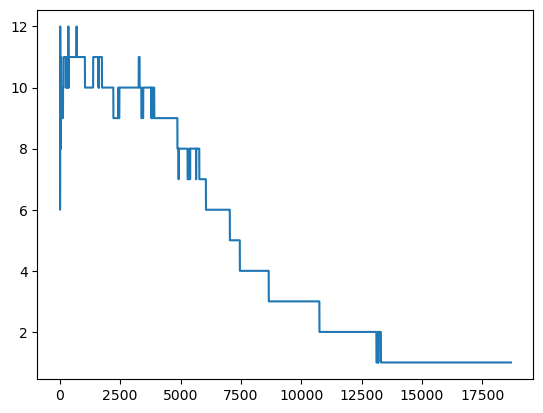

In [39]:
plt.plot(long_dfs.groupby('frame').size())

In [40]:
find_initial(long_dfs, 11, merge_new_summarize)

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next
9,9,364,1035,671,"[1679.0, 1127.0, 7.0, 8.0]","[1633.0, 1071.0, 17.0, 13.0]","[1682.06432748538, 1130.9649122807018]","[1641.4642233856891, 1077.479930191972]",appear,merge,"([], [])","([12], [1036])"
11,11,308,1035,727,"[1663.0, 1092.0, 17.0, 36.0]","[1651.0, 1076.0, 17.0, 15.0]","[1672.1158594491926, 1110.3570750237416]","[1656.54802259887, 1084.4896421845574]",merge,merge,"([6, 10], [307, 307])","([12], [1036])"
17,17,156,3019,2863,"[1830.0, 971.0, 20.0, 10.0]","[1908.0, 1316.0, 17.0, 17.0]","[1839.512658227848, 975.120253164557]","[1916.5677966101696, 1324.3954802259886]",split,merge,"([31], [155])","([23], [3020])"
19,19,5,3373,3368,"[1684.0, 1019.0, 17.0, 9.0]","[1589.0, 1661.0, 24.0, 10.0]","[1691.2994011976048, 1023.1736526946108]","[1600.8697916666667, 1665.1857638888887]",appear,merge,"([], [])","([25], [3374])"
24,24,8,3373,3365,"[1712.0, 1121.0, 9.0, 12.0]","[1613.0, 1651.0, 22.0, 13.0]","[1715.1140350877192, 1126.3552631578948]","[1625.5159574468084, 1658.904255319149]",appear,merge,"([], [])","([25], [3374])"
28,28,286,5645,5359,"[1796.0, 953.0, 17.0, 14.0]","[1602.0, 668.0, 19.0, 16.0]","[1803.6438095238093, 959.7142857142856]","[1611.817543859649, 675.0315789473684]",split,merge,"([33], [285])","([38], [5646])"
29,29,26,5775,5749,"[1504.0, 1068.0, 13.0, 10.0]","[1310.0, 1757.0, 7.0, 11.0]","[1511.1866666666665, 1073.26]","[1312.575163398693, 1761.8692810457514]",split,disappear,"([1], [25])","([], [])"
34,34,286,7040,6754,"[1814.0, 955.0, 25.0, 9.0]","[1185.0, 1674.0, 12.0, 6.0]","[1825.6247619047615, 959.3238095238096]","[1190.4666666666667, 1676.6333333333334]",split,disappear,"([33], [285])","([], [])"
37,37,128,5645,5517,"[1800.0, 925.0, 13.0, 20.0]","[1585.0, 666.0, 24.0, 11.0]","[1805.5279383429672, 933.2793834296724]","[1595.7099358974358, 669.9294871794871]",split,merge,"([36], [127])","([38], [5646])"
40,40,18,8652,8634,"[1550.0, 877.0, 7.0, 8.0]","[1171.0, 283.0, 11.0, 7.0]","[1553.3144654088048, 880.7295597484276]","[1176.0503144654087, 285.9937106918239]",appear,disappear,"([], [])","([], [])"


In [41]:
all_ini = find_initial(long_dfs, 11, merge_new_summarize)
tmp_indx = all_ini.sort_values(by="start_frame").num.values
all_ini.loc[tmp_indx]

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next
19,19,5,3373,3368,"[1684.0, 1019.0, 17.0, 9.0]","[1589.0, 1661.0, 24.0, 10.0]","[1691.2994011976048, 1023.1736526946108]","[1600.8697916666667, 1665.1857638888887]",appear,merge,"([], [])","([25], [3374])"
24,24,8,3373,3365,"[1712.0, 1121.0, 9.0, 12.0]","[1613.0, 1651.0, 22.0, 13.0]","[1715.1140350877192, 1126.3552631578948]","[1625.5159574468084, 1658.904255319149]",appear,merge,"([], [])","([25], [3374])"
40,40,18,8652,8634,"[1550.0, 877.0, 7.0, 8.0]","[1171.0, 283.0, 11.0, 7.0]","[1553.3144654088048, 880.7295597484276]","[1176.0503144654087, 285.9937106918239]",appear,disappear,"([], [])","([], [])"
29,29,26,5775,5749,"[1504.0, 1068.0, 13.0, 10.0]","[1310.0, 1757.0, 7.0, 11.0]","[1511.1866666666665, 1073.26]","[1312.575163398693, 1761.8692810457514]",split,disappear,"([1], [25])","([], [])"
37,37,128,5645,5517,"[1800.0, 925.0, 13.0, 20.0]","[1585.0, 666.0, 24.0, 11.0]","[1805.5279383429672, 933.2793834296724]","[1595.7099358974358, 669.9294871794871]",split,merge,"([36], [127])","([38], [5646])"
17,17,156,3019,2863,"[1830.0, 971.0, 20.0, 10.0]","[1908.0, 1316.0, 17.0, 17.0]","[1839.512658227848, 975.120253164557]","[1916.5677966101696, 1324.3954802259886]",split,merge,"([31], [155])","([23], [3020])"
28,28,286,5645,5359,"[1796.0, 953.0, 17.0, 14.0]","[1602.0, 668.0, 19.0, 16.0]","[1803.6438095238093, 959.7142857142856]","[1611.817543859649, 675.0315789473684]",split,merge,"([33], [285])","([38], [5646])"
34,34,286,7040,6754,"[1814.0, 955.0, 25.0, 9.0]","[1185.0, 1674.0, 12.0, 6.0]","[1825.6247619047615, 959.3238095238096]","[1190.4666666666667, 1676.6333333333334]",split,disappear,"([33], [285])","([], [])"
11,11,308,1035,727,"[1663.0, 1092.0, 17.0, 36.0]","[1651.0, 1076.0, 17.0, 15.0]","[1672.1158594491926, 1110.3570750237416]","[1656.54802259887, 1084.4896421845574]",merge,merge,"([6, 10], [307, 307])","([12], [1036])"
9,9,364,1035,671,"[1679.0, 1127.0, 7.0, 8.0]","[1633.0, 1071.0, 17.0, 13.0]","[1682.06432748538, 1130.9649122807018]","[1641.4642233856891, 1077.479930191972]",appear,merge,"([], [])","([12], [1036])"


In [42]:
banned_list = np.array([])
worm1, banned_list = simple_find_nex(tmp_indx[0], merge_new_summarize, banned_list)
worm2, banned_list = simple_find_nex(tmp_indx[1], merge_new_summarize, banned_list)
worm3, banned_list = simple_find_nex(tmp_indx[2], merge_new_summarize, banned_list)
worm4, banned_list = simple_find_nex(tmp_indx[3], merge_new_summarize, banned_list)
worm5, banned_list = simple_find_nex(tmp_indx[4], merge_new_summarize, banned_list)
worm6, banned_list = simple_find_nex(tmp_indx[5], merge_new_summarize, banned_list)
worm7, banned_list = simple_find_nex(tmp_indx[6], merge_new_summarize, banned_list)
worm8, banned_list = simple_find_nex(tmp_indx[7], merge_new_summarize, banned_list)
worm9, banned_list = simple_find_nex(tmp_indx[8], merge_new_summarize, banned_list)
worm10, banned_list = simple_find_nex(tmp_indx[9], merge_new_summarize, banned_list)
# worm11, banned_list = simple_find_nex(tmp_indx[], merge_new_summarize, banned_list)

summary_worms_df = pd.DataFrame(columns=['num','start_index','end_index','start_frame', 'end_frame', 'length'])
for i in range(1, 11):
    summary_worms_df.loc[len(summary_worms_df)] = [i,
                                                   merge_new_summarize.loc[[eval("worm{}".format(i))[0]]].index.values[0],
                                                   merge_new_summarize.loc[[eval("worm{}".format(i))[-1]]].index.values[0],
                                                   merge_new_summarize.loc[eval("worm{}".format(i))[0]]['start_frame'],
                                                   merge_new_summarize.loc[eval("worm{}".format(i))[-1]]['end_frame'], len(eval("worm{}".format(i)))]
    

summary_worms_df.sort_values(by="start_frame").loc[summary_worms_df.start_frame > 200]


,num,start_index,end_index,start_frame,end_frame,length
6,7,28,41,286,10752,3
7,8,34,34,286,7040,1
8,9,11,14,308,1740,4
9,10,9,43,364,13300,6


In [43]:
all_ini

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next
9,9,364,1035,671,"[1679.0, 1127.0, 7.0, 8.0]","[1633.0, 1071.0, 17.0, 13.0]","[1682.06432748538, 1130.9649122807018]","[1641.4642233856891, 1077.479930191972]",appear,merge,"([], [])","([12], [1036])"
11,11,308,1035,727,"[1663.0, 1092.0, 17.0, 36.0]","[1651.0, 1076.0, 17.0, 15.0]","[1672.1158594491926, 1110.3570750237416]","[1656.54802259887, 1084.4896421845574]",merge,merge,"([6, 10], [307, 307])","([12], [1036])"
17,17,156,3019,2863,"[1830.0, 971.0, 20.0, 10.0]","[1908.0, 1316.0, 17.0, 17.0]","[1839.512658227848, 975.120253164557]","[1916.5677966101696, 1324.3954802259886]",split,merge,"([31], [155])","([23], [3020])"
19,19,5,3373,3368,"[1684.0, 1019.0, 17.0, 9.0]","[1589.0, 1661.0, 24.0, 10.0]","[1691.2994011976048, 1023.1736526946108]","[1600.8697916666667, 1665.1857638888887]",appear,merge,"([], [])","([25], [3374])"
24,24,8,3373,3365,"[1712.0, 1121.0, 9.0, 12.0]","[1613.0, 1651.0, 22.0, 13.0]","[1715.1140350877192, 1126.3552631578948]","[1625.5159574468084, 1658.904255319149]",appear,merge,"([], [])","([25], [3374])"
28,28,286,5645,5359,"[1796.0, 953.0, 17.0, 14.0]","[1602.0, 668.0, 19.0, 16.0]","[1803.6438095238093, 959.7142857142856]","[1611.817543859649, 675.0315789473684]",split,merge,"([33], [285])","([38], [5646])"
29,29,26,5775,5749,"[1504.0, 1068.0, 13.0, 10.0]","[1310.0, 1757.0, 7.0, 11.0]","[1511.1866666666665, 1073.26]","[1312.575163398693, 1761.8692810457514]",split,disappear,"([1], [25])","([], [])"
34,34,286,7040,6754,"[1814.0, 955.0, 25.0, 9.0]","[1185.0, 1674.0, 12.0, 6.0]","[1825.6247619047615, 959.3238095238096]","[1190.4666666666667, 1676.6333333333334]",split,disappear,"([33], [285])","([], [])"
37,37,128,5645,5517,"[1800.0, 925.0, 13.0, 20.0]","[1585.0, 666.0, 24.0, 11.0]","[1805.5279383429672, 933.2793834296724]","[1595.7099358974358, 669.9294871794871]",split,merge,"([36], [127])","([38], [5646])"
40,40,18,8652,8634,"[1550.0, 877.0, 7.0, 8.0]","[1171.0, 283.0, 11.0, 7.0]","[1553.3144654088048, 880.7295597484276]","[1176.0503144654087, 285.9937106918239]",appear,disappear,"([], [])","([], [])"


In [44]:
banned_list_prev = banned_list
# worm6_prev, banned_list_prev = simple_find_prev(worm6[0], merge_new_summarize, banned_list_prev)
worm7_prev, banned_list_prev = simple_find_prev(worm7[0], merge_new_summarize, banned_list_prev)
worm8_prev, banned_list_prev = simple_find_prev(worm8[0], merge_new_summarize, banned_list_prev)
worm9_prev, banned_list_prev = simple_find_prev(worm9[0], merge_new_summarize, banned_list_prev)
worm10_prev, banned_list_prev = simple_find_prev(worm10[0], merge_new_summarize, banned_list_prev)

In [45]:
# worm6 = np.concatenate([worm6_prev[:-1], worm6])
worm7 = np.concatenate([worm7_prev[:-1], worm7])
worm8 = np.concatenate([worm8_prev[:-1], worm8])
worm9 = np.concatenate([worm9_prev[:-1], worm9])
worm10 = np.concatenate([worm10_prev[:-1], worm10])

In [46]:
summary_worms_df = pd.DataFrame(columns=['num','start_index','end_index','start_frame', 'end_frame', 'length'])
for i in range(1, 11):
    summary_worms_df.loc[len(summary_worms_df)] = [i,
                                                   merge_new_summarize.loc[[eval("worm{}".format(i))[0]]].index.values[0],
                                                   merge_new_summarize.loc[[eval("worm{}".format(i))[-1]]].index.values[0],
                                                   merge_new_summarize.loc[eval("worm{}".format(i))[0]]['start_frame'],
                                                   merge_new_summarize.loc[eval("worm{}".format(i))[-1]]['end_frame'], len(eval("worm{}".format(i)))]
    

summary_worms_df.sort_values(by="start_frame").loc[summary_worms_df.start_frame > 200]


,num,start_index,end_index,start_frame,end_frame,length
9,10,7,43,352,13300,7


In [47]:
n22_new_pic = "./n22_new_trackers"
os.path.isdir(n22_new_pic) and shutil.rmtree(n22_new_pic)
os.path.isdir(n22_new_pic) or os.makedirs(n22_new_pic)
for j in range(1, 11):
    worm_indx = j
    fig, ax = plt.subplots(figsize=(15,10))
    for i in eval("worm{}".format(worm_indx))[:]:
        plt.plot(*np.array(new_trackers_2[i]['centroids'][:]).T, label=i)
        plt.scatter(*np.array(new_trackers_2[i]['centroids'][0]).T)
        plt.scatter(*np.array(new_trackers_2[i]['centroids'][-1]).T, marker='x', c=1)

    ax.set_xlim(0, 3072)
    ax.set_ylim(0, 2048)
    ax.legend()


    plotly_fig = mpl_to_plotly(fig)
    pio.write_html(plotly_fig, file=os.path.join(n22_new_pic,"worm{:02d}.html".format(worm_indx)), auto_open=True)

/Users/zhengpanpan/miniconda3/lib/python3.12/site-packages/plotly/matplotlylib/renderer.py:609: UserWarning:

I found a path object that I don't think is part of a bar chart. Ignoring.



# Apply4

In [59]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil

from plotly.tools import mpl_to_plotly
import plotly.io as pio
from iou import *

In [60]:
with open('n2.json', "r") as f:
    all_trackers = json.load(f)
long_dfs = pd.read_csv('all_dfs_n2.csv', index_col="frame")
long_dfs.index = long_dfs.index.astype(int)
all_trackers = {int(k): v for k, v in all_trackers.items()}

trackers_summarize = generate_summarize(all_trackers)
trackers_type_df = pd.DataFrame(columns=["num", "left_type", "right_type", "left_prev", "right_next"])
for i in range(len(trackers_summarize)):
    tmp_df = trackers_summarize.iloc[i]
    tmp_left_type, tmp_right_type, left_prev, right_next = edge_type(tmp_df, long_dfs, all_trackers)
    trackers_type_df.loc[len(trackers_type_df)] = [tmp_df.num, tmp_left_type, tmp_right_type, left_prev, right_next]
    
merge_trackers_summarize = pd.merge(trackers_summarize, trackers_type_df, on="num")

print(len(all_trackers))

106


In [61]:
merge_trackers_summarize

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next
0,0,14,24,10,"[919.0, 1141.0, 9.0, 15.0]","[920.0, 1136.0, 7.0, 11.0]","[923.020618556701, 1148.316151202749]","[923.125786163522, 1140.7610062893082]",appear,merge,"([], [])","([10], [25])"
1,1,34,40,6,"[1498.0, 695.0, 9.0, 9.0]","[1496.0, 691.0, 16.0, 21.0]","[1502.4088050314465, 699.2327044025157]","[1505.0210526315789, 701.2964912280701]",split,split,"([39], [33])","([2, 39], [41, 41])"
2,2,41,77,36,"[1504.0, 699.0, 10.0, 13.0]","[1497.0, 685.0, 13.0, 19.0]","[1507.8122977346277, 705.3398058252427]","[1503.3218390804595, 693.0689655172414]",split,disappear,"([1], [40])","([], [])"
3,3,79,90,11,"[1498.0, 685.0, 8.0, 11.0]","[1499.0, 683.0, 6.0, 10.0]","[1501.3480392156862, 689.1813725490196]","[1501.3630952380952, 687.6428571428571]",appear,disappear,"([], [])","([], [])"
4,4,93,117,24,"[1498.0, 687.0, 10.0, 9.0]","[1496.0, 686.0, 11.0, 20.0]","[1502.2201257861634, 689.7044025157231]","[1501.7267267267266, 695.0210210210209]",appear,disappear,"([], [])","([], [])"
...,...,...,...,...,...,...,...,...,...,...,...,...
101,101,3497,4050,553,"[1677.0, 839.0, 14.0, 15.0]","[1624.0, 1070.0, 12.0, 17.0]","[1683.3243243243244, 844.4972972972973]","[1629.0029895366215, 1078.9237668161436]",split,disappear,"([100], [3496])","([], [])"
102,102,3689,4050,361,"[1392.0, 846.0, 10.0, 19.0]","[1429.0, 790.0, 18.0, 16.0]","[1396.5281803542673, 854.3204508856682]","[1438.6200873362443, 797.2940320232896]",appear,disappear,"([], [])","([], [])"
103,103,3698,4050,352,"[1396.0, 871.0, 15.0, 30.0]","[1204.0, 1098.0, 19.0, 14.0]","[1403.7948028673834, 885.9086021505376]","[1213.419568822554, 1104.4825870646766]",appear,disappear,"([], [])","([], [])"
104,104,3698,4050,352,"[1406.0, 855.0, 16.0, 17.0]","[1461.0, 776.0, 13.0, 20.0]","[1413.5223880597016, 863.0331674958541]","[1467.6992592592592, 786.0962962962963]",appear,disappear,"([], [])","([], [])"


In [62]:
split_from_df = pd.concat([split_from(i, merge_trackers_summarize) for i in range(len(merge_trackers_summarize))], ignore_index=True)
split_from_df = split_from_df.loc[split_from_df.is_split == True]
tmp_all_num = []
for i in range(len(split_from_df)):
    nex_num = split_from_df.iloc[i].nex_num
    diff = split_from_df.iloc[i]['difference']
    nex_start = split_from_df.iloc[i]["nex_start"]
    this_num = split_from_df.iloc[i].this_num

    tmp_df = pd.DataFrame(columns=['tracker_num', 'split_frame'])

    for i,j in zip(nex_start, diff):
        if j != 0:
            tmp_df.loc[len(tmp_df)] = [this_num, i]
    tmp_all_num.append(tmp_df)
    # print(tmp_df)
if len(tmp_all_num) == 0:
    pass
else:
    critical_split_df = pd.concat(tmp_all_num, ignore_index=True)

    new_trackers = {}
    ini_indx = 0
    for i in range(len(all_trackers)):
        if i not in critical_split_df.tracker_num.values:
            new_trackers[ini_indx] = all_trackers[i]
            ini_indx += 1
        else:
            split_result = split_trackers(i, critical_split_df, all_trackers)
            for j in split_result:
                new_trackers[ini_indx] = j
                ini_indx += 1


In [63]:
len(new_trackers)

123

In [64]:
merge_to_df = pd.concat([merge_to(i, merge_new_summarize) for i in range(len(merge_new_summarize))], ignore_index=True)
merge_to_df = merge_to_df.loc[merge_to_df.is_merge == True]
tmp_all_num = []
for i in range(len(merge_to_df)):
    diff = merge_to_df.iloc[i]['difference']
    nex_start = merge_to_df.iloc[i]["nex_end"]
    this_num = merge_to_df.iloc[i].this_num

    tmp_df = pd.DataFrame(columns=['tracker_num', 'split_frame'])

    for i,j in zip(nex_start, diff):
        if j != 0:
            tmp_df.loc[len(tmp_df)] = [this_num, i]
    tmp_all_num.append(tmp_df)
    # print(tmp_df)
print(len(tmp_all_num))

if len(tmp_all_num) == 0:
    new_trackers_2 = new_trackers
    pass
else:
    critical_merge_df = pd.concat(tmp_all_num, ignore_index=True)
    critical_merge_df.split_frame += 1

    new_trackers_2 = {}
    ini_indx = 0
    for i in range(len(new_trackers)):
        if i not in critical_merge_df.tracker_num.values:
            new_trackers_2[ini_indx] = new_trackers[(i)]
            ini_indx += 1
        else:
            split_result = split_trackers(i, critical_merge_df, new_trackers)
            for j in split_result:
                new_trackers_2[ini_indx] = j
                ini_indx += 1


20


In [65]:
new_summarize_2 = generate_summarize(new_trackers_2)

trackers_type_df = pd.DataFrame(columns=["num", "left_type", "right_type", "left_prev", "right_next"])
for i in range(len(new_summarize_2)):
    tmp_df = new_summarize_2.iloc[i]
    tmp_left_type, tmp_right_type, left_prev, right_next = edge_type(tmp_df, long_dfs, new_trackers_2)
    trackers_type_df.loc[len(trackers_type_df)] = [tmp_df.num, tmp_left_type, tmp_right_type, left_prev, right_next]

merge_new_summarize = pd.merge(new_summarize_2, trackers_type_df, on="num")

In [66]:
all_ini = find_initial(long_dfs, 13, merge_new_summarize)
tmp_indx = all_ini.sort_values(by="start_frame").num.values
all_ini.loc[tmp_indx].loc[all_ini.loc[tmp_indx].start_frame > 200].shape

(8, 12)

In [67]:
banned_list = np.array([])
worm1, banned_list = simple_find_nex(tmp_indx[0], merge_new_summarize, banned_list)
worm2, banned_list = simple_find_nex(tmp_indx[1], merge_new_summarize, banned_list)
worm3, banned_list = simple_find_nex(tmp_indx[2], merge_new_summarize, banned_list)
worm4, banned_list = simple_find_nex(tmp_indx[3], merge_new_summarize, banned_list)
worm5, banned_list = simple_find_nex(tmp_indx[4], merge_new_summarize, banned_list)
worm6, banned_list = simple_find_nex(tmp_indx[5], merge_new_summarize, banned_list)
worm7, banned_list = simple_find_nex(tmp_indx[6], merge_new_summarize, banned_list)
worm8, banned_list = simple_find_nex(tmp_indx[7], merge_new_summarize, banned_list)
worm9, banned_list = simple_find_nex(tmp_indx[8], merge_new_summarize, banned_list)
worm10, banned_list = simple_find_nex(tmp_indx[9], merge_new_summarize, banned_list)
worm11, banned_list = simple_find_nex(tmp_indx[10], merge_new_summarize, banned_list)
worm12, banned_list = simple_find_nex(tmp_indx[11], merge_new_summarize, banned_list)
worm13, banned_list = simple_find_nex(tmp_indx[12], merge_new_summarize, banned_list)

banned_list_prev = banned_list
worm6_prev, banned_list_prev = simple_find_prev(tmp_indx[5], merge_new_summarize, banned_list_prev)
worm7_prev, banned_list_prev = simple_find_prev(tmp_indx[6], merge_new_summarize, banned_list_prev)
worm8_prev, banned_list_prev = simple_find_prev(tmp_indx[7], merge_new_summarize, banned_list_prev)
worm9_prev, banned_list_prev = simple_find_prev(tmp_indx[8], merge_new_summarize, banned_list_prev)
worm10_prev, banned_list_prev = simple_find_prev(tmp_indx[9], merge_new_summarize, banned_list_prev)
worm11_prev, banned_list_prev = simple_find_prev(tmp_indx[10], merge_new_summarize, banned_list_prev)
worm12_prev, banned_list_prev = simple_find_prev(tmp_indx[11], merge_new_summarize, banned_list_prev)
worm13_prev, banned_list_prev = simple_find_prev(tmp_indx[12], merge_new_summarize, banned_list_prev)
worm6 = np.concatenate([worm6_prev[:-1], worm6])
worm7 = np.concatenate([worm7_prev[:-1], worm7])
worm8 = np.concatenate([worm8_prev[:-1], worm8])
worm9 = np.concatenate([worm9_prev[:-1], worm9])
worm10 = np.concatenate([worm10_prev[:-1], worm10])
worm11 = np.concatenate([worm11_prev[:-1], worm11])
worm12 = np.concatenate([worm12_prev[:-1], worm12])
worm13 = np.concatenate([worm13_prev[:-1], worm13])
error_worm_indx = []
for i in range(1, 13):
    tmp_worm = eval("worm{}".format(i))
    if tmp_worm[-1] == -1:
        error_worm_indx.append(i)
        print("worm{} is a dead end".format(i))
    if tmp_worm[0] == -1:
        error_worm_indx.append(i)
        print("worm{} is a dead start".format(i))
    
print(np.unique(error_worm_indx).shape[0])

$[113] all path banned
$[103  95] all path banned
$[120] all path banned
$[113] all path banned
$[24] all path banned
worm9 is a dead end
worm10 is a dead end
worm10 is a dead start
worm11 is a dead end
3


In [68]:
new_path = "n2"
os.path.isdir(new_path) and shutil.rmtree(new_path)
os.path.isdir(new_path) or os.makedirs(new_path)
for k in range(1, 13):
    if k in error_worm_indx:
        continue
    tmp_worm = eval("worm{}".format(k))
    fig,ax = plt.subplots(figsize=(15,10))
    for i,j in enumerate(tmp_worm):
        # print(j)
        ax.plot(*np.array(new_trackers_2[j]['centroids'][::]).T, label=j)
        if j != tmp_worm[-1]:
            tmp_indx = tmp_worm[i+1]
            ax.plot(*np.array([new_trackers_2[j]['centroids'][-1], new_trackers_2[tmp_indx]['centroids'][0]]).T, 'k-.')


    ax.set_xlim(0, 3072)
    ax.set_ylim(0, 2048)
    ax.legend()
    plotly_fig = mpl_to_plotly(fig)
    pio.write_html(plotly_fig, file=os.path.join(new_path,"worm{:02d}.html".format(k)), auto_open=True)


/Users/zhengpanpan/miniconda3/lib/python3.12/site-packages/plotly/matplotlylib/renderer.py:609: UserWarning:

I found a path object that I don't think is part of a bar chart. Ignoring.



In [69]:
merge_new_summarize.loc[[22

,num,start_frame,end_frame,durations,start_bbox,end_bbox,start_centroids,end_centroids,left_type,right_type,left_prev,right_next
22,22,1283,1287,4,"[2042.0, 1008.0, 14.0, 8.0]","[2043.0, 1008.0, 15.0, 8.0]","[2049.233830845771, 1011.4029850746268]","[2050.121863799283, 1011.7204301075268]",appear,disappear,"([], [])","([], [])"
